In [4]:
!pip install numpy pandas matplotlib


     ---------------------------------------- 11.3/11.3 MB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 509.2/509.2 kB 3.5 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 2.8 MB/s eta 0:00:00
     ---------------------------------------- 2.3/2.3 MB 952.3 kB/s eta 0:00:00
     -------------------------------------- 73.8/73.8 kB 815.4 kB/s eta 0:00:00
     ---------------------------------------- 7.0/7.0 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 121.8/121.8 kB 3.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install seaborn


     -------------------------------------- 294.9/294.9 kB 1.1 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)

In [8]:
df = pd.read_csv("ADBL.csv")

In [9]:
df.head()

,Symbol,Date,Open,High,Low,Close,Percent Change,Volume,Turnover,Daily_Return,...,EMA_26,RSI_14,MACD,MACD_Signal,ATR_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,OBV
0,ADBL,2012-01-01,115.0,115.0,113.0,114.0,-0.87 %,1111.0,125973.0,NaN,...,114.000000,18.819188,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0
1,ADBL,2012-01-02,114.0,118.0,115.0,118.0,3.51 %,551.0,64227.0,0.035088,...,114.296296,26.214341,0.319088,0.063818,NaN,NaN,NaN,NaN,NaN,551.0
2,ADBL,2012-01-03,118.0,116.0,114.0,115.0,-2.54 %,490.0,56130.0,-0.025424,...,114.348422,27.589938,0.326134,0.116281,NaN,NaN,NaN,NaN,NaN,61.0
3,ADBL,2012-01-04,115.0,115.0,113.0,114.0,-0.87 %,3220.0,369040.0,-0.008696,...,114.322613,36.328662,0.248165,0.142658,NaN,NaN,NaN,NaN,NaN,-3159.0
4,ADBL,2012-01-05,114.0,114.0,112.0,113.0,-0.88 %,775.0,87595.0,-0.008772,...,114.224642,38.978141,0.104478,0.135022,NaN,NaN,NaN,NaN,NaN,-3934.0


In [10]:
print("Dataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3131 entries, 0 to 3130
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          3131 non-null   object 
 1   Date            3131 non-null   object 
 2   Open            3131 non-null   float64
 3   High            3131 non-null   float64
 4   Low             3131 non-null   float64
 5   Close           3131 non-null   float64
 6   Percent Change  3131 non-null   object 
 7   Volume          3131 non-null   float64
 8   Turnover        3131 non-null   float64
 9   Daily_Return    3130 non-null   float64
 10  Log_Return      3130 non-null   float64
 11  SMA_5           3127 non-null   float64
 12  SMA_20          3112 non-null   float64
 13  EMA_12          3131 non-null   float64
 14  EMA_26          3131 non-null   float64
 15  RSI_14          3118 non-null   float64
 16  MACD            3131 non-null   float64
 17  MACD_Signal     313

In [11]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Symbol             0
Date               0
Open               0
High               0
Low                0
Close              0
Percent Change     0
Volume             0
Turnover           0
Daily_Return       1
Log_Return         1
SMA_5              4
SMA_20            19
EMA_12             0
EMA_26             0
RSI_14            13
MACD               0
MACD_Signal        0
ATR_14            13
BB_Middle         19
BB_Std            19
BB_Upper          19
BB_Lower          19
OBV                0
dtype: int64


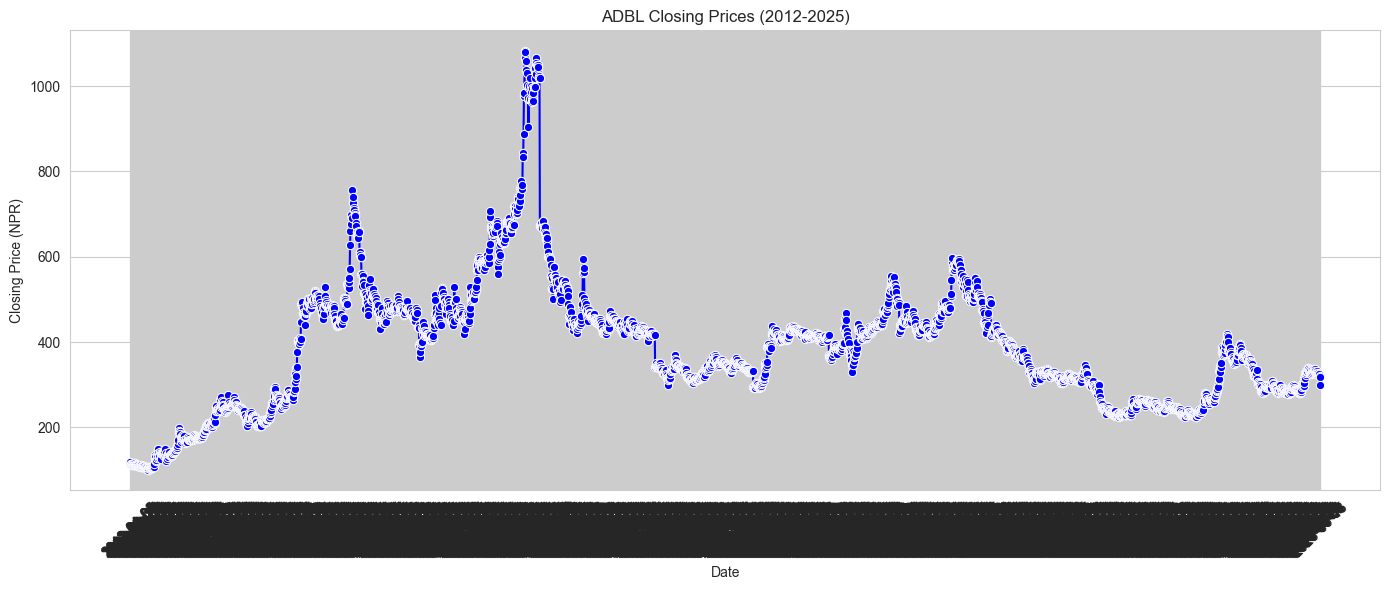

In [12]:
plt.figure(figsize=(14,6))
sns.set_style("whitegrid")
sns.lineplot(data=df, x='Date', y='Close', marker='o', color='blue')
plt.xticks(rotation=45)
plt.title('ADBL Closing Prices (2012-2025)')
plt.xlabel('Date')
plt.ylabel('Closing Price (NPR)')
plt.tight_layout()
plt.show()

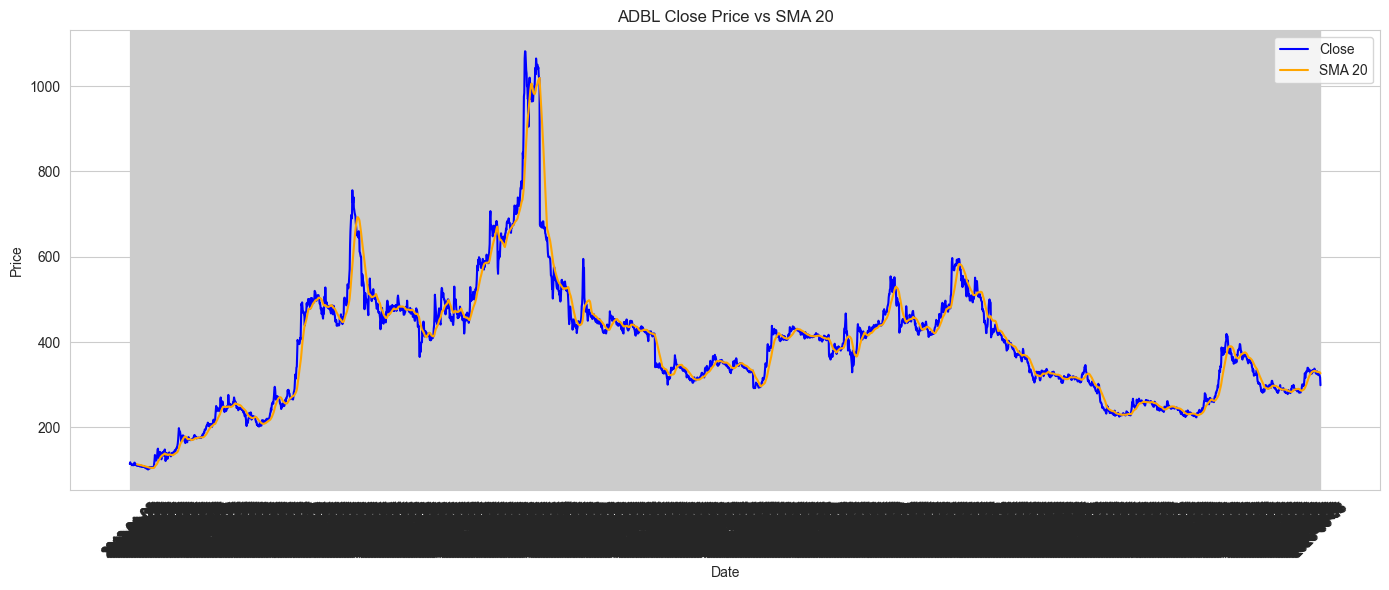

In [13]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='Date', y='Close', label='Close', color='blue')
sns.lineplot(data=df, x='Date', y='SMA_20', label='SMA 20', color='orange')
plt.xticks(rotation=45)
plt.title('ADBL Close Price vs SMA 20')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

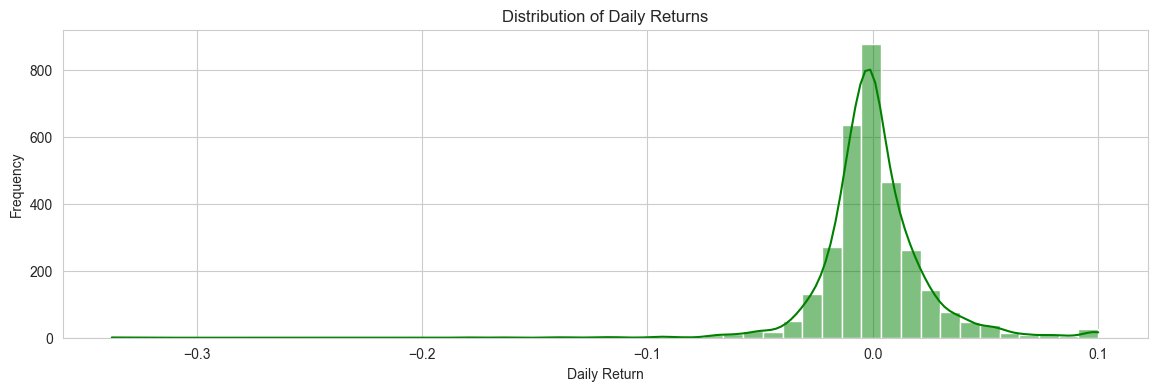

In [14]:
if 'Daily_Return' not in df.columns:
    df['Daily_Return'] = df['Close'].pct_change()
    
plt.figure(figsize=(14,4))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()